In [1]:
import sys, os
sys.path.insert(0, '/home/okonias/projects/td-mpc_o2')
sys.path.insert(0, '/home/okonias/projects/td-mpc_o2/tdmpc/src')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import torch
import numpy as np
import time
from pathlib import Path
from omegaconf import OmegaConf
from cfg import parse_cfg
from env import make_env
from algorithm.helper import Episode, ReplayBuffer, linear_schedule
from o2.tdmpc_o2 import TDMPC_O2
from o2.training_utils import set_seed, update_tdmpc, update_decoder
from o2.eval_utils import evaluate_agent

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
O2_DEFAULTS = {
    'latent_action_dim': 128, 'decoder_init': False, 'use_latent_state': True,
    'dcem_batch_size': 64, 'decoder_updates': 100, 'told_updates': 500,
    'decoder_start_steps': 5000, 'exp_name': 'o2_ddpg',
    'latent_num_samples': 32, 'latent_num_elites': 8, 'dcem_sampling_n': None,
}

CFG_PATH = Path('/home/okonias/projects/td-mpc_o2/tdmpc/cfgs')
sys.argv = ['train', 'task=cheetah-run', 'seed=20']
cfg = parse_cfg(CFG_PATH)
cfg = OmegaConf.merge(OmegaConf.create(O2_DEFAULTS), cfg)

ar = cfg.action_repeat  # already set from task yaml
cfg = OmegaConf.merge(cfg, OmegaConf.create({
    'iterations' : 5,
    'told_updates' : 500,
    'decoder_updates': 80,

    # evaluation
    'eval_episodes': 0,
    'video_mode':    'none',

    # training — divided by action_repeat so wall-clock steps are consistent
    'train_steps':  40000 // ar,
    'seed_steps':   4000 // ar,   #CHANGE THIS
    'episode_length':   1000 // ar,

    # schedules — end step also divided by action_repeat
    'horizon_schedule':  f'linear(1, ${{horizon}}, {25000 // ar})',     #AND THIs
    'std_schedule':      f'linear(0.5, ${{min_std}}, {25000 // ar})',

    'decoder_start_steps':  0 // ar,
    'dcem_batch_size':   128,         #CHANGE THIS

    'use_latent_state': False,
    'decoder_init':   None,

    #'load_model': "models/cheetah-run20k/model.pt",
    #'load_buffer':  "models/cheetah-run20k/replay_buffer.pth",

    'momentum'          : 0.1,
    'use_is_weights'    : True,
    'lml_temperature'   : 1,
    'dec_grad_clip_norm': 1,

    'latent_action_dim': 128,
    'lambda_gae':        0.5,
    'diversity_coeff':   0.01,
    'log_det_target' :   -6,
    'use_raw_obs': True,


}))
# Override anything here:
# cfg.lr = 3e-4
# cfg.decoder_start_steps = 2000

print(OmegaConf.to_yaml(cfg))

latent_action_dim: 128
decoder_init: null
use_latent_state: false
dcem_batch_size: 128
decoder_updates: 80
told_updates: 500
decoder_start_steps: 0
exp_name: default
latent_num_samples: 32
latent_num_elites: 8
dcem_sampling_n: null
task: cheetah-run
modality: state
action_repeat: 4
discount: 0.99
episode_length: 250
train_steps: 10000
iterations: 5
num_samples: 512
num_elites: 64
mixture_coef: 0.05
min_std: 0.05
temperature: 0.5
momentum: 0.1
batch_size: 512
max_buffer_size: 1000000
horizon: 5
reward_coef: 0.5
value_coef: 0.1
consistency_coef: 2
rho: 0.5
kappa: 0.1
lr: 0.001
std_schedule: linear(0.5, ${min_std}, 6250)
horizon_schedule: linear(1, ${horizon}, 6250)
per_alpha: 0.6
per_beta: 0.4
grad_clip_norm: 10
seed_steps: 1000
update_freq: 2
tau: 0.01
enc_dim: 256
mlp_dim: 512
latent_dim: 50
use_wandb: false
wandb_project: none
wandb_entity: none
seed: 20
eval_freq: 20000
eval_episodes: 0
save_video: false
save_model: false
task_title: Cheetah Run
device: cuda
video_mode: none
use_is_w

In [15]:
set_seed(cfg.seed)
env    = make_env(cfg)
agent  = TDMPC_O2(cfg)
buffer = ReplayBuffer(cfg)
step, episode_idx = 0, 0
start_time = time.time()
print('Ready')

Ready


In [5]:
if cfg.get('load_model', None):
    d = torch.load(cfg.load_model)
    state_dict = d['model'] if 'model' in d else d
    for k in [k for k in state_dict if k.startswith('_action_decoder') or k.startswith('_V')]:
        del state_dict[k]
    agent.model.load_state_dict(state_dict, strict=False)
    if 'model_target' in d:
        target_dict = d['model_target']
        for k in [k for k in target_dict if k.startswith('_action_decoder') or k.startswith('_V')]:
            del target_dict[k]
        agent.model_target.load_state_dict(target_dict, strict=False)
        print("Target loaded")
    else:
        agent.model_target.load_state_dict(agent.model.state_dict(), strict=False)
        print("Target copied")
    print(f'Loaded model from {cfg.load_model}')
if cfg.get('load_buffer', None):
    buffer.__dict__.update(torch.load(cfg.load_buffer, weights_only=False))
    print(f'Loaded buffer from {cfg.load_buffer}')


Target loaded
Loaded model from models/cheetah-run20k/model.pt
Loaded buffer from models/cheetah-run20k/replay_buffer.pth


In [6]:

# --- Decoder pretraining ---
agent.cfg.decoder_updates = 300
dec_metrics = update_decoder(agent, buffer, cfg, step=0)
agent.cfg.decoder_updates =  100

for k, v in dec_metrics.items():
    if k != 'grad_tracker':
        print(f'  {k:<20}: {v:>8.4f}')

  decoder_loss        : -25.4280
  value_cost          : -35.2518
  diversity_cost      :  -0.0032
  diversity_alpha     :   0.0096
  decoder_grad_norm   :   1.0532
  value_mean          :  35.2518
  saturation          :   1.0809
  z_norm              :   4.6930
  u_norm              :  10.6979
  hidden_norm         :  12.5190
  lambda_gae          :   0.5000
  action_var          :   0.1444
  gmm_diversity       :   0.3474
  gmm_pi_balance      :   0.3621
  gmm_mu_0_norm       :   1.3277
  gmm_sigma_0_trace   :   1.1556
  gmm_mu_1_norm       :   1.3306
  gmm_sigma_1_trace   :   1.1513
  gmm_inter_spread    :   0.8126
  u_mean_norm         :  10.6979
  u_std_mean          :   1.6690
  decoder_grad_norm_max:   3.4154


In [16]:
num_episodes = 20
W = 38

for _ in range(num_episodes):
    phase = 'o2' if step >= cfg.decoder_start_steps else 'tdmpc'
    obs = env.reset()
    episode = Episode(cfg, obs)
    t_ep = time.time()

    while not episode.done:
        if step < cfg.seed_steps:
            action = torch.tensor(env.action_space.sample(), dtype=torch.float32, device=agent.device)
        elif phase == 'tdmpc':
            action = agent.plan(obs, step=step, t0=episode.first)
        else:
            action, *_ = agent.CEM_in_latent(obs, step=step, sample_final_action=True)

        obs, reward, done, _ = env.step(action.cpu().numpy())
        episode += (obs, action, reward, done)
    buffer += episode
    ep_time = time.time() - t_ep

    step += cfg.episode_length
    episode_idx += 1
    env_step = int(step * cfg.action_repeat)
    print('─' * W)
    print(f'  Episode {episode_idx}   step {env_step:,}   [{phase}]')
    print('─' * W)
    print(f'  {"Reward":<16}: {episode.cumulative_reward:>8.1f}')
    print(f'  {"Horizon":<16}: {int(linear_schedule(cfg.horizon_schedule, step)):>8}')
    print(f'  {"Std":<16}: {linear_schedule(cfg.std_schedule, step):>8.3f}')
    print(f'  {"Ep time":<16}: {ep_time:>7.1f}s')


    train_metrics, update_time = {}, 0.0
    if step >= cfg.seed_steps:
        t = time.time()
        train_metrics = update_tdmpc(agent, buffer, step)
        update_time = time.time() - t

    dec_metrics = {}
    decoder_time = 0.0
    if (phase == 'o2' and step >= cfg.seed_steps):
        t = time.time()
        dec_metrics = update_decoder(agent, buffer, cfg, step)
        decoder_time = time.time() - t
        for iteration, norm in sorted(dec_metrics['grad_tracker']):
            print(f'  DCEM iter {iteration} grad norm: {norm:.6f}')



    print(f'  {"Update time":<16}: {update_time:>7.1f}s')
    if dec_metrics:
        print(f'  {"Decoder time":<16}: {decoder_time:>7.1f}s')
        for k, v in dec_metrics.items():
            if k != 'grad_tracker':
                print(f'  {k:<20}: {v:>8.4f}')
    print(f'  {"Total time":<16}: {time.time() - start_time:>7.0f}s')

    if train_metrics:
        for k, v in train_metrics.items():
            print(f'  {k:<20}: {v:>8.4f}')



──────────────────────────────────────
  Episode 1   step 1,000   [o2]
──────────────────────────────────────
  Reward          :     14.3
  Horizon         :        1
  Std             :    0.482
  Ep time         :     0.3s
  Update time     :     0.0s
  Total time      :       2s
──────────────────────────────────────
  Episode 2   step 2,000   [o2]
──────────────────────────────────────
  Reward          :     13.9
  Horizon         :        1
  Std             :    0.464
  Ep time         :     0.2s
  Update time     :     0.0s
  Total time      :       2s
──────────────────────────────────────
  Episode 3   step 3,000   [o2]
──────────────────────────────────────
  Reward          :     13.1
  Horizon         :        1
  Std             :    0.446
  Ep time         :     0.2s
  Update time     :     0.0s
  Total time      :       3s
──────────────────────────────────────
  Episode 4   step 4,000   [o2]
──────────────────────────────────────
  Reward          :     32.5
  Horizon

KeyboardInterrupt: 

Saturation fraction per dim: [0.158 0.023 0.142 0.225 0.14  0.212]
Variance per dim:           [0.271 0.163 0.463 0.238 0.263 0.296]
Uniform [-1,1] variance:    0.333


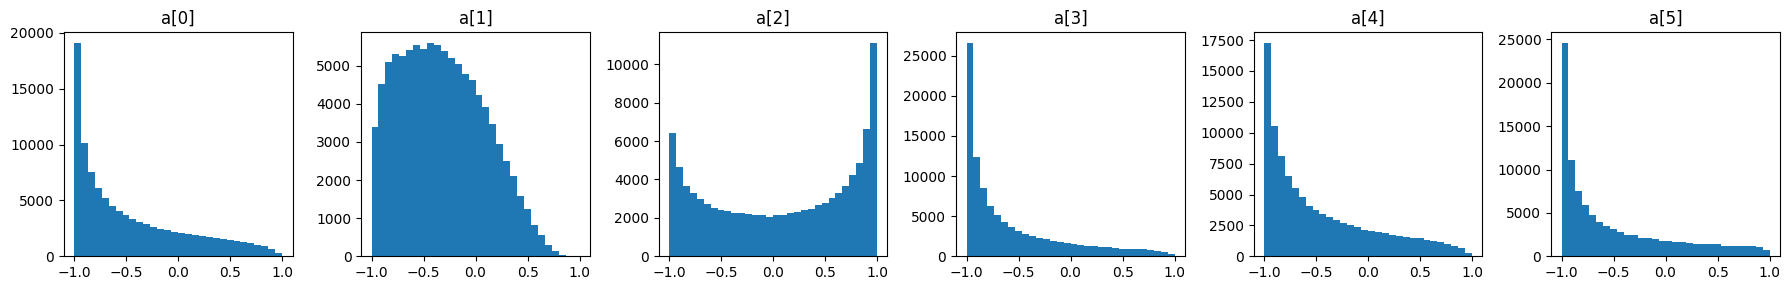

NameError: name 'u_samples' is not defined

In [7]:
n = 100000
obs_batch = buffer.sample()[0][:1].repeat(n, 1)
u = torch.randn(n, cfg.latent_action_dim, device=agent.device)
cond = obs_batch if cfg.use_raw_obs else agent.model_target.h(obs_batch).detach()

with torch.no_grad():
    seq, pretanh = agent.model.decode_sequence(u, cond, return_pretanh=True)
    actions = seq[0]      # [n, action_dim] — first horizon step
    pt      = pretanh[0]  # [n, action_dim] — pre-tanh values

# Saturation fraction — fraction of outputs near the bounds
sat_fraction = (actions.abs() > 0.95).float().mean(dim=0)  # per action dim
print("Saturation fraction per dim:", sat_fraction.cpu().numpy().round(3))

# Bimodality: compare variance to what a uniform on [-1,1] would give (=1/3)
# If variance >> 1/3, mass is piling at the extremes
var_per_dim = actions.var(dim=0)
print("Variance per dim:          ", var_per_dim.cpu().numpy().round(3))
print("Uniform [-1,1] variance:    0.333")

# Histogram per action dim
import matplotlib.pyplot as plt
A = actions.shape[1]
fig, axes = plt.subplots(1, A, figsize=(3*A, 3))
for i, ax in enumerate(axes):
    ax.hist(actions[:, i].cpu().numpy(), bins=30, range=(-1, 1))
    ax.set_title(f'a[{i}]')
plt.tight_layout()
plt.show()
import gc
import torch
del seq, pretanh, actions, u_samples, u_mean, u_std
gc.collect()
torch.cuda.empty_cache()


In [17]:

import gc
import torch

del seq, pretanh, actions, u_samples, u_mean, u_std
gc.collect()
torch.cuda.empty_cache()
B = 1000
obs_batch = buffer.sample()[0][:B]

_, u_mean, u_std, *_ = agent.DCEM(obs_batch, step=step)
u_mean = u_mean.detach()
u_std  = u_std.detach()

u_samples = u_mean + u_std * torch.randn_like(u_mean)  # [B, latent_dim]

cond = obs_batch if cfg.use_raw_obs else agent.model_target.h(obs_batch).detach()
with torch.no_grad():
    seq, pretanh = agent.model.decode_sequence(u_samples, cond, return_pretanh=True)
    actions = seq[0].cpu()  # [B, action_dim]

A = actions.shape[1]
print("Saturation fraction per dim:", (actions.abs() > 0.95).float().mean(dim=0).numpy().round(3))
print("Variance per dim:           ", actions.var(dim=0).numpy().round(3))
print("Mean per dim:               ", actions.mean(dim=0).numpy().round(3))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, A, figsize=(3*A, 3))
for i, ax in enumerate(axes if A > 1 else [axes]):
    ax.hist(actions[:, i].numpy(), bins=20, range=(-1, 1))
    ax.axvline(0, color='r', linestyle='--', alpha=0.5)
    ax.set_title(f'a[{i}]')
    ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 11.76 GiB of which 2.25 MiB is free. Including non-PyTorch memory, this process has 11.74 GiB memory in use. Of the allocated memory 11.53 GiB is allocated by PyTorch, and 38.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [24]:
import gc
import torch


gc.collect()
torch.cuda.empty_cache()

In [7]:


eval_metrics = evaluate_agent(
    env,
    agent,
    cfg,
    step=step,
    n_episodes=1,
    use_latent=True,
    save_dir='eval_videos',
    video_mode='first'   # or 'first'
)


Episode 1/1: Reward = 369.507
🎥 Saved first episode video: eval_videos/videos/eval_step5000_ep001.mp4

Evaluation Summary — Step 5000
-------------------------
Mean Reward: 369.507
Std Reward:  0.000


In [16]:
import torch
del agent, buffer  # or whatever large objects
torch.cuda.empty_cache()

In [ ]:
import torch.nn.utils as utils
import pandas as pd
#PAIRWISE DISTANCES LOSS, DIAGONAL ELEMENTS INCLUDED
def update_decoder_DDPG(self, obs, u_mean, horizon, weights=None, log_det_loss=None, u_std=None):
    self.action_dec_optim.zero_grad()

    k     = getattr(self.cfg, 'diversity_k_samples', 3)
    #sigma = getattr(self.cfg, 'diversity_sigma', 0.1)
    B     = u_mean.shape[0]

    z      = self.model.h(obs).detach()
    z_norm = z.norm(dim=-1).mean().item()
    u_norm = u_mean.norm(dim=-1).mean().item()

    min_std   = self.std
    noise     = torch.randn(k, B, u_mean.shape[-1], device=z.device)
    u_samples = u_mean.unsqueeze(0) + u_std.clamp(min=min_std).unsqueeze(0) * noise


    u_flat    = u_samples.permute(1, 0, 2).reshape(B * k, -1)
    z_rep     = z.repeat_interleave(k, dim=0)

    seqs, pretanh = self.model.decode_sequence(u_flat, z_rep, return_pretanh=True)
    saturation    = pretanh.abs().mean().item()

    #values = self.estimate_value_with_grad(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    values = self.estimate_value_GAE(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    seqs_bk = seqs[:horizon].reshape(horizon, B, k, -1).permute(1, 2, 0, 3).flatten(2)

    values_bk = values.reshape(B, k)

    v         = (values_bk - values_bk.min(dim=1, keepdim=True).values.detach()).clamp(min=1e-6)
    #v         = values_bk.clamp(min=1e-6)
    #v = values_bk.clamp(min=1e-6)
    dists     = torch.cdist(seqs_bk, seqs_bk)
    sigma     = dists.detach().mean().clamp(min=1e-6)


    scaled_dists = 1 + dists/sigma    # linear growth, starts at 1 like exp
    #scaled_dists = torch.exp((dists/sigma).clamp(max=3))

    #v_weights    = v.unsqueeze(2) * v.unsqueeze(1)
    v_weights = v.sqrt().unsqueeze(2) * v.sqrt().unsqueeze(1)
    #v_weights = v.sqrt().unsqueeze(2) * v.sqrt().unsqueeze(1)
    mask      = torch.triu(torch.ones(k, k, device=z.device, dtype=torch.bool), diagonal=0)
    cost      = -(v_weights * scaled_dists)[: , mask].mean()
    cost.backward()


    k = v.shape[1]

    cost_matrix         = (v_weights * scaled_dists).detach().mean(dim=0).cpu().numpy()
    dist_matrix         = dists.detach().mean(dim=0).cpu().numpy()
    dist_score_matrix = scaled_dists.detach().mean(dim=0).cpu().numpy()
    val_matrix          = v_weights.detach().mean(dim=0).cpu().numpy()

    df_cost       = pd.DataFrame(cost_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_dist       = pd.DataFrame(dist_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_dist_score = pd.DataFrame(dist_score_matrix.round(3), index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])
    df_val        = pd.DataFrame(val_matrix.round(3),  index=[f"s{i}" for i in range(k)], columns=[f"s{j}" for j in range(k)])

    print("=== distances ===");       print(df_dist.to_string())
    print("=== exp_dists ===");       print(df_dist_score.to_string())
    print("=== value weights ===");   print(df_val.to_string())
    print("=== cost matrix ===");     print(df_cost.to_string())

    seqs_bk_unflat = seqs[:horizon].reshape(horizon, B, k, -1).permute(1, 2, 0, 3)

    per_step_dists = []
    for t in range(horizon):
        d_t = torch.cdist(seqs_bk_unflat[:, :, t, :], seqs_bk_unflat[:, :, t, :])  # [B, k, k]
        mask = torch.triu(torch.ones(k, k, dtype=torch.bool, device=d_t.device), diagonal=1)
        per_step_dists.append(d_t[:, mask].mean().item())

    for t, d in enumerate(per_step_dists):
        print(f"  t={t}: mean_dist = {d:.4f}")
    print(f"  total (flattened): {dists.detach()[:, mask].mean().item():.4f}")

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), dec_grad_clip)
    self.action_dec_optim.step()

    return {
        'decoder_loss':      cost.item(),
        'decoder_grad_norm': grad_norm.item(),
        'value_mean':        values_bk.mean().item(),
        'saturation':        saturation,
        'z_norm':            z_norm,
        'u_norm':            u_norm,
        'hidden_norm':       self.model._action_decoder._hidden_norm,
    }
setattr(TDMPC_O2, "update_decoder_DDPG", update_decoder_DDPG)

In [ ]:
import torch.nn.utils as utils
import pandas as pd
#DPP LOSS
def update_decoder_DDPG(self, obs, u_mean, horizon, weights=None, log_det_loss=None):
    self.action_dec_optim.zero_grad()

    k     = getattr(self.cfg, 'diversity_k_samples', 8)
    sigma_noise = getattr(self.cfg, 'diversity_sigma', 0.05)
    B     = u_mean.shape[0]

    z      = self.model.h(obs).detach()
    z_norm = z.norm(dim=-1).mean().item()
    u_norm = u_mean.norm(dim=-1).mean().item()

    noise     = torch.randn(k, B, u_mean.shape[-1], device=z.device)
    u_samples = u_mean.unsqueeze(0) + sigma_noise * noise
    u_flat    = u_samples.permute(1, 0, 2).reshape(B * k, -1)
    z_rep     = z.repeat_interleave(k, dim=0)

    seqs, pretanh = self.model.decode_sequence(u_flat, z_rep, return_pretanh=True)
    saturation    = pretanh.abs().mean().item()

    values = self.estimate_value_with_grad(z_rep, seqs, horizon).nan_to_num(0).squeeze(-1)

    seqs_bk   = seqs.reshape(horizon, B, k, -1).permute(1, 2, 0, 3).flatten(2)
    values_bk = values.reshape(B, k)

    v     = (values_bk - values_bk.min(dim=1, keepdim=True).values.detach()).clamp(min=1e-6)
    dists = torch.cdist(seqs_bk, seqs_bk)
    sigma = getattr(self.cfg, 'dpp_sigma', 1.0)
    K     = torch.exp(-dists**2 / (2 * sigma**2))
    L     = v.unsqueeze(2) * K * v.unsqueeze(1)
    L     = L + 1e-4 * torch.eye(k, device=z.device).unsqueeze(0)
    sign, logdet = torch.linalg.slogdet(L)
    cost  = -(sign * logdet).mean()

    cost.backward()

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), dec_grad_clip)
    self.action_dec_optim.step()

    with torch.no_grad():
        L_print = L.detach().mean(dim=0)
        df = pd.DataFrame(L_print.cpu().numpy().round(3),
                          index=[f"s{i}" for i in range(k)],
                          columns=[f"s{j}" for j in range(k)])
        print(df.to_string())

    return {
        'decoder_loss':      cost.item(),
        'decoder_grad_norm': grad_norm.item(),
        'value_mean':        values_bk.mean().item(),
        'saturation':        saturation,
        'z_norm':            z_norm,
        'u_norm':            u_norm,
        'hidden_norm':       self.model._action_decoder._hidden_norm,
    }
setattr(TDMPC_O2, "update_decoder_DDPG", update_decoder_DDPG)

In [ ]:
import torch.nn.utils as utils
def action_decoder_DDPG_update_v2(self, obs, u_mean, u_std, horizon, weights=None):
    """
    DDPG-style decoder update with entropy regularization and saturation penalty.

    Two saturation penalty options are available — select by uncommenting:
      Option 1 (inline jacobian penalty): fast, uses pretanh values directly.
      Option 2 (saturation_loss):         sampled, captures full distribution.

    Args:
        obs:     [B, obs_dim] observation batch from the replay buffer.
        u_mean:  [B, latent_action_dim] differentiable latent action mean
                 obtained from DCEMethod(update_mode=True).
        u_std:   [B, latent_action_dim] differentiable latent action std
                 obtained from DCEMethod(update_mode=True).
        horizon: int planning horizon.

    Returns:
        dict with keys: decoder_loss, decoder_grad_norm, saturation
    """
    # Are any TOLD params mistakenly receiving grads?
    for name, p in agent.model.named_parameters():
        if '_action_decoder' not in name and '_V' not in name:
            assert not p.requires_grad, f"TOLD param not frozen: {name}"

    self.action_dec_optim.zero_grad()

    z                 = self.model.h(obs).detach()
    sequence, pretanh = self.model.decode_sequence_pretanh(u_mean, z)
    value             = self.estimate_value_with_grad(z, sequence, horizon).nan_to_num(0).squeeze(-1)
    saturation        = pretanh.abs().mean().item()

    # --- Option 1: inline jacobian penalty [B], subtracted per batch element ---
    jacobian_penalty  = -torch.log(1 - sequence.pow(2) + 1e-6).sum(-1).mean(0)  # [B]
    per_sample_cost   = -(value - self.cfg.saturation_coeff * jacobian_penalty)
    if weights is not None:
        cost = (per_sample_cost * weights).mean()
    else:
        cost = per_sample_cost.mean()

    # --- Option 2: saturation_loss (sampled across distribution) [B] ---
    #saturation_coeff  = getattr(self.cfg, 'saturation_coeff', 0.0)
    #sat_loss          = self.saturation_loss(u_mean, u_std, z) if saturation_coeff > 0 else 0.0
    #per_sample_cost   = -(value - saturation_coeff * sat_loss)
    #if weights is not None:
    #    cost = (per_sample_cost * weights).mean()
    #else:
    #    cost = per_sample_cost.mean()
    cost.backward()

    grad_norm = torch.sqrt(sum(
        p.grad.norm() ** 2
        for p in self.model._action_decoder.parameters() if p.grad is not None
    ))
    dec_grad_clip = getattr(self.cfg, 'dec_grad_clip_norm', None)
    if dec_grad_clip:
        utils.clip_grad_norm_(self.model._action_decoder.parameters(), max_norm=dec_grad_clip)
    self.action_dec_optim.step()

    return {'decoder_loss': cost.item(), 'decoder_grad_norm': grad_norm.item(), 'saturation': saturation}



setattr(TDMPC_O2, "action_decoder_DDPG_update_v2", action_decoder_DDPG_update_v2)


In [ ]:
from o2.eval_utils import evaluate_agent

metrics = evaluate_agent(
    env, agent, cfg,
    step=0,
    n_episodes=1,
    save_dir='./eval_output',
    video_mode='first',
)
for k, v in metrics.items():
    print(f'  {k:<20}: {v:>8.4f}')

Episode 1/1: Reward = 67.106
🎥 Saved first episode video: ./eval_output/videos/eval_step0_ep001.mp4

Evaluation Summary — Step 0
-------------------------
Mean Reward: 67.106
Std Reward:  0.000
  step                :   0.0000
  mean_reward         :  67.1056
  std_reward          :   0.0000
  mean_compute_duration:   0.0052
  episode_duration    :  22.3075


TypeError: unsupported format string passed to list.__format__